# FCGMB Benchmark Statistics

This notebook generates all statistics reported in the Results section of the FCGMB paper.

**Data files used:**
- `data/chembl_targets.csv` - Human single-protein targets from ChEMBL36
- `data/chembl_pdb_map.csv` - Target-PDB-ligand mapping
- `data/chembl_pdb_druglike.csv` - After drug-likeness filtering
- `data/chembl_docking_benchmark.csv` - Final benchmark entries
- `data/mcs_results.csv` - MCS computation results

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Data directory
DATA_DIR = Path('../data')

print("Data files available:")
for f in DATA_DIR.glob('*.csv'):
    print(f"  - {f.name}: {f.stat().st_size / 1e6:.2f} MB")

Data files available:
  - chembl_docking_benchmark.csv: 3.94 MB
  - chembl_pdb_druglike.csv: 6.30 MB
  - chembl_pdb_map.csv: 12.26 MB
  - chembl_targets.csv: 0.32 MB
  - mcs_results.csv: 0.32 MB


## 1. Target and Structure Identification

Statistics from the initial ChEMBL and PDB data retrieval.

In [2]:
# Load targets data
df_targets = pd.read_csv(DATA_DIR / 'chembl_targets.csv')

n_targets = len(df_targets)
print(f"Human single-protein targets in ChEMBL36: {n_targets:,}")
print(f"\nSample targets:")
df_targets.head()

Human single-protein targets in ChEMBL36: 5,820

Sample targets:


,target_chembl_id,target_name,uniprot_id
0,CHEMBL2074,Maltase-glucoamylase,O43451
1,CHEMBL1971,ATP-binding cassette sub-family C member 9,O60706
2,CHEMBL1827,"cGMP-specific 3',5'-cyclic phosphodiesterase",O76074
3,CHEMBL1859,Voltage-dependent T-type calcium channel subun...,O95180
4,CHEMBL202,Dihydrofolate reductase,P00374


In [3]:
# Load PDB mapping data
df_pdb = pd.read_csv(DATA_DIR / 'chembl_pdb_map.csv')

print("PDB Structure Mapping Statistics:")
print("=" * 50)

print(f"Number of total unique PDB structures: {df_pdb['pdb_id'].nunique()}")
df_pdb_holo = df_pdb[df_pdb['is_holo'] == True]
print(f"Number of unique targets with holo: {df_pdb_holo['target_chembl_id'].nunique()}")
print(f"Number of holo structures: {df_pdb_holo['pdb_id'].nunique()}")
print(f"Number of PDB-ligand combinations: {df_pdb_holo.drop_duplicates(['pdb_id', 'ligand_resname']).shape[0]}")
print(f"Number of unique ligands: {df_pdb_holo['ligand_resname'].nunique()}")

PDB Structure Mapping Statistics:
Number of total unique PDB structures: 63250
Number of unique targets with holo: 2674
Number of holo structures: 40771
Number of PDB-ligand combinations: 56519
Number of unique ligands: 23080


## 2. Drug-Likeness Filtering

Statistics after applying drug-likeness criteria:
- Molecular weight: 200-800 Da
- At least 1 ring
- Contains N or O
- LogP: -2 to 7
- Rotatable bonds: ≤15

In [4]:
# Load drug-like filtered data
df_druglike = pd.read_csv(DATA_DIR / 'chembl_pdb_druglike.csv')

print("After Drug-Likeness Filtering:")
print("=" * 50)

print(f"Unique targets: {df_druglike['target_chembl_id'].nunique():,}")
print(f"Unique PDB structures: {df_druglike['pdb_id'].nunique():,}")
print(f"Unique PDB-ligand combinations: {df_druglike.drop_duplicates(['pdb_id', 'ligand_resname']).shape[0]:,}")
print(f"Unique ligand resnames: {df_druglike['ligand_resname'].nunique():,}")


After Drug-Likeness Filtering:
Unique targets: 1,842
Unique PDB structures: 27,630
Unique PDB-ligand combinations: 30,287
Unique ligand resnames: 18,441


## 3. Bioactivity Data Integration (Benchmark Matches)

Statistics on crystal ligands matched to ChEMBL assays.

In [5]:
# Load benchmark data
df_bench = pd.read_csv(DATA_DIR / 'chembl_docking_benchmark.csv')

print("Benchmark Matches (Reference Ligands in ChEMBL Assays):")
print("=" * 60)

n_benchmark = len(df_bench)
n_targets_bench = df_bench['target_chembl_id'].nunique()
n_pdb_bench = df_bench['pdb_id'].nunique()
n_docs = df_bench['document_chembl_id'].nunique()
n_assays = df_bench['assay_chembl_id'].nunique()
n_ligands = df_bench['ligand_resname'].nunique()

print(f"Total benchmark entries: {n_benchmark:,}")
print(f"Unique targets: {n_targets_bench:,}")
print(f"Unique PDB structures: {n_pdb_bench:,}")
print(f"Unique documents: {n_docs:,}")
print(f"Unique assays: {n_assays:,}")
print(f"Unique ligands: {n_ligands:,}")
print(f"Unique PDB-ligand pairs: {df_bench.drop_duplicates(['pdb_id', 'ligand_resname']).shape[0]:,}")

Benchmark Matches (Reference Ligands in ChEMBL Assays):
Total benchmark entries: 18,324
Unique targets: 633
Unique PDB structures: 6,023
Unique documents: 3,950
Unique assays: 4,841
Unique ligands: 4,548
Unique PDB-ligand pairs: 6,051


In [6]:
df_mcs = pd.read_csv(DATA_DIR / 'mcs_results.csv')

In [7]:
df_mcs['document_chembl_id'].nunique(), df_mcs['assay_chembl_id'].nunique()

(3141, 3950)

In [8]:
len(df_mcs[df_mcs['mcs_smiles'].isna()])

166

In [9]:
df_merged = df_mcs.merge(df_bench, on=['assay_chembl_id', 'document_chembl_id'])
df_merged = df_merged.dropna(subset=['mcs_smiles'])
print(f"Unique targets: {df_merged['target_chembl_id'].nunique()}")
print(f"Unique PDB structures: {df_merged['pdb_id'].nunique()}")
print(f"Unique PDB-ligand pairs: {len(df_merged.drop_duplicates(['pdb_id', 'ligand_resname']))}")
print(f"Unique ligands: {df_merged['ligand_resname'].nunique()}")
print(f"Unique assays: {df_merged['assay_chembl_id'].nunique()}")
print(f"Unique documents: {df_merged['document_chembl_id'].nunique()}")

Unique targets: 417
Unique PDB structures: 4281
Unique PDB-ligand pairs: 4296
Unique ligands: 3191
Unique assays: 3784
Unique documents: 3059


In [10]:
df_config = pd.read_csv('../generated_configs/config_index.csv')
print('Unique targets:', df_config['target_chembl_id'].nunique())
print('Unique PDB structures:', df_config['pdb_id'].nunique())
print('Unique PDB-ligand pairs:', df_config[['pdb_id', 'ligand_resname']].drop_duplicates().shape[0])
print('Unique ligands:', df_config['ligand_resname'].nunique())
print('Unique assays:', df_config['assay_chembl_id'].nunique())
print('Unique documents:', df_config['document_chembl_id'].nunique())

Unique targets: 327
Unique PDB structures: 2882
Unique PDB-ligand pairs: 2890
Unique ligands: 2240
Unique assays: 2267
Unique documents: 1892


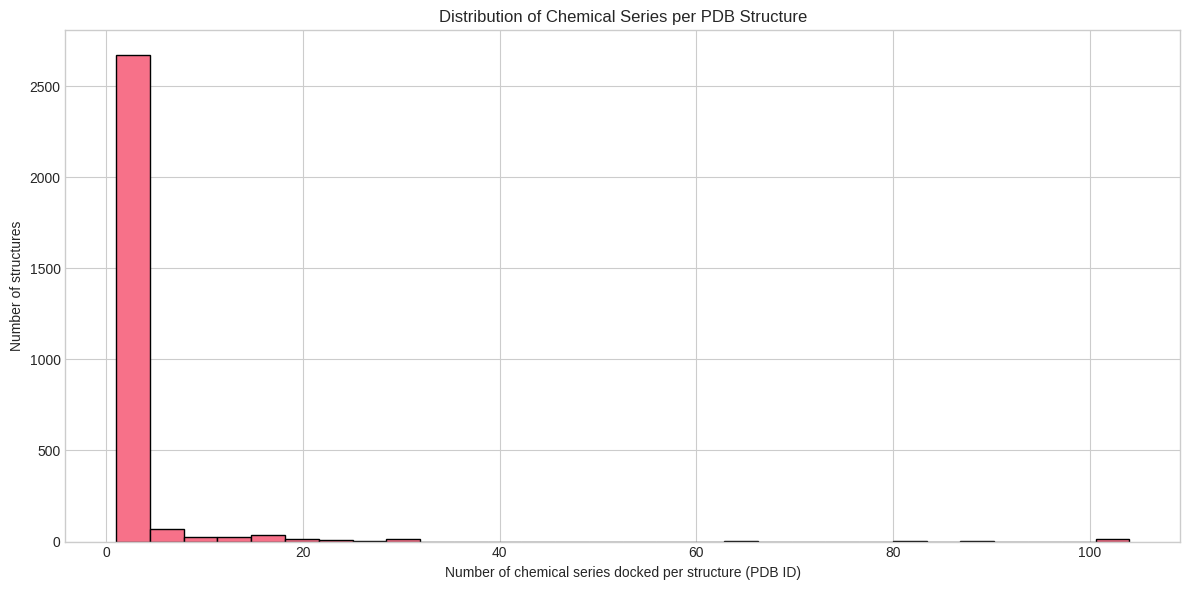

In [23]:
import matplotlib.pyplot as plt

pdb_counts = df_config['pdb_id'].value_counts()

plt.figure(figsize=(12, 6))
plt.hist(pdb_counts, bins=30, edgecolor='black')
plt.xlabel('Number of chemical series docked per structure (PDB ID)')
plt.ylabel('Number of structures')
plt.title('Distribution of Chemical Series per PDB Structure')
plt.tight_layout()
plt.show()

In [11]:
len(df_config)

7792

In [12]:
# Document type breakdown
if 'document_type' in df_bench.columns:
    print("\nBy document type:")
    doc_counts = df_bench['document_type'].value_counts()
    for dtype, count in doc_counts.items():
        pct = 100 * count / n_benchmark
        print(f"  {dtype}: {count:,} ({pct:.1f}%)")

# Crystal ligand in assay
if 'crystal_in_assay' in df_bench.columns:
    n_crystal_in_assay = df_bench['crystal_in_assay'].sum()
    print(f"\nCrystal ligand in assay (exact match): {n_crystal_in_assay:,}")


By document type:
  literature: 16,608 (90.6%)
  other: 1,716 (9.4%)

Crystal ligand in assay (exact match): 18,324


In [13]:
df_bench.head(5)

,target_chembl_id,target_name,uniprot_id,pdb_id,resolution,ligand_resname,crystal_smiles,document_chembl_id,assay_chembl_id,document_type,n_compounds_in_assay,n_matches,best_match_smiles,best_similarity,crystal_in_assay,median_pchembl
0,CHEMBL1900,Aldo-keto reductase family 1 member B1,P15121,1US0,0.66,LDT,c1cc(c(cc1F)OCC(=O)O)C(=S)NCc2ccc(cc2F)Br,CHEMBL1140501,CHEMBL924228,literature,28,1,O=C(O)COc1cc(F)ccc1C(=S)NCc1ccc(Br)cc1F,1.0,True,7.195
1,CHEMBL1900,Aldo-keto reductase family 1 member B1,P15121,3BCJ,0.78,FIS,c1cc2c(cc1F)[C@]3(C[C@H](O2)C(=O)N)C(=O)NC(=O)N3,CHEMBL1140501,CHEMBL924228,literature,28,2,NC(=O)[C@H]1C[C@]2(NC(=O)NC2=O)c2cc(F)ccc2O1,1.0,True,7.195
2,CHEMBL1900,Aldo-keto reductase family 1 member B1,P15121,2QXW,0.80,LDT,c1cc(c(cc1F)OCC(=O)O)C(=S)NCc2ccc(cc2F)Br,CHEMBL1140501,CHEMBL924228,literature,28,1,O=C(O)COc1cc(F)ccc1C(=S)NCc1ccc(Br)cc1F,1.0,True,7.195
3,CHEMBL1900,Aldo-keto reductase family 1 member B1,P15121,2I16,0.81,LDT,c1cc(c(cc1F)OCC(=O)O)C(=S)NCc2ccc(cc2F)Br,CHEMBL1140501,CHEMBL924228,literature,28,1,O=C(O)COc1cc(F)ccc1C(=S)NCc1ccc(Br)cc1F,1.0,True,7.195
4,CHEMBL1900,Aldo-keto reductase family 1 member B1,P15121,2I17,0.81,LDT,c1cc(c(cc1F)OCC(=O)O)C(=S)NCc2ccc(cc2F)Br,CHEMBL1140501,CHEMBL924228,literature,28,1,O=C(O)COc1cc(F)ccc1C(=S)NCc1ccc(Br)cc1F,1.0,True,7.195


## 4. Structural Quality Assessment

Resolution statistics for benchmark structures.

In [14]:
if 'resolution' in df_bench.columns:
    res = df_bench['resolution'].dropna()
    
    print("Structure Resolution Statistics:")
    print("=" * 50)
    print(f"Mean: {res.mean():.2f} Å")
    print(f"Median: {res.median():.2f} Å")
    print(f"Range: {res.min():.2f} - {res.max():.2f} Å")
    print(f"Std Dev: {res.std():.2f} Å")
    
    # Resolution thresholds
    n_2_0 = (res <= 2.0).sum()
    n_2_5 = (res <= 2.5).sum()
    n_3_0 = (res <= 3.0).sum()
    
    print(f"\nEntries by resolution threshold:")
    print(f"  ≤2.0 Å: {n_2_0:,} ({100*n_2_0/len(res):.1f}%)")
    print(f"  ≤2.5 Å: {n_2_5:,} ({100*n_2_5/len(res):.1f}%)")
    print(f"  ≤3.0 Å: {n_3_0:,} ({100*n_3_0/len(res):.1f}%)")

Structure Resolution Statistics:
Mean: 2.15 Å
Median: 2.05 Å
Range: 0.66 - 7.80 Å
Std Dev: 0.58 Å

Entries by resolution threshold:
  ≤2.0 Å: 8,830 (48.8%)
  ≤2.5 Å: 13,842 (76.4%)
  ≤3.0 Å: 16,677 (92.1%)


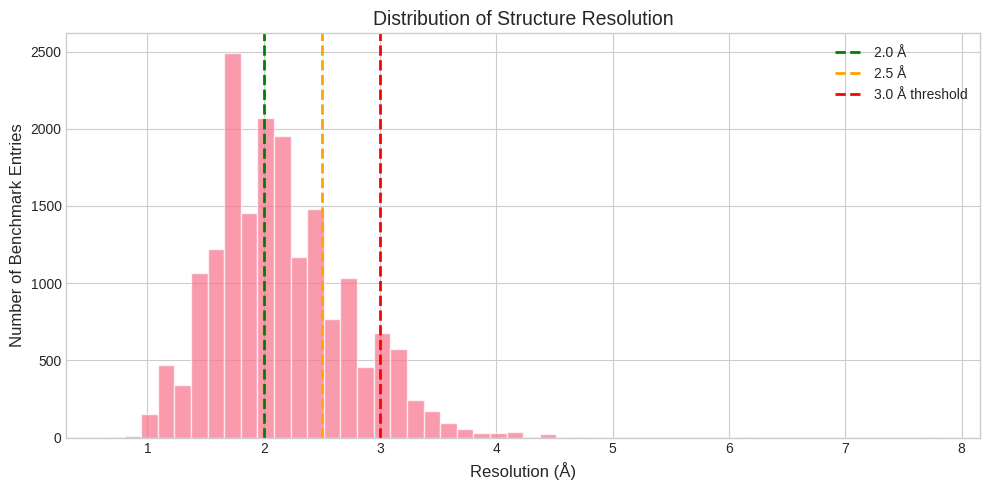

In [15]:
# Resolution distribution plot
if 'resolution' in df_bench.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    res_valid = df_bench['resolution'].dropna()
    
    ax.hist(res_valid, bins=50, edgecolor='white', alpha=0.7)
    ax.axvline(2.0, color='green', linestyle='--', linewidth=2, label='2.0 Å')
    ax.axvline(2.5, color='orange', linestyle='--', linewidth=2, label='2.5 Å')
    ax.axvline(3.0, color='red', linestyle='--', linewidth=2, label='3.0 Å threshold')
    
    ax.set_xlabel('Resolution (Å)', fontsize=12)
    ax.set_ylabel('Number of Benchmark Entries', fontsize=12)
    ax.set_title('Distribution of Structure Resolution', fontsize=14)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('../results_resolution_distribution.png', dpi=150)
    plt.show()

## 5. Maximum Common Substructure Analysis

In [16]:
# Load MCS results
df_mcs = pd.read_csv(DATA_DIR / 'mcs_results.csv')

print("MCS Computation Results:")
print("=" * 50)

n_total_mcs = len(df_mcs)
n_success = df_mcs['mcs_smiles'].notna().sum()
n_failed = n_total_mcs - n_success

print(f"Total assays processed: {n_total_mcs:,}")
print(f"Successful MCS computations: {n_success:,} ({100*n_success/n_total_mcs:.1f}%)")
print(f"Failed/no MCS: {n_failed:,} ({100*n_failed/n_total_mcs:.1f}%)")

MCS Computation Results:
Total assays processed: 3,950
Successful MCS computations: 3,784 (95.8%)
Failed/no MCS: 166 (4.2%)


## 6. Generated Benchmark Configurations

In [17]:
# Count generated configs
config_dirs = [
    Path('../generated_configs'),
    Path('../configs'),
    Path('../fcgmb/configs')
]

print("Generated Benchmark Configurations:")
print("=" * 50)

for cdir in config_dirs:
    if cdir.exists():
        yamls = list(cdir.glob('*.yaml')) + list(cdir.glob('*.yml'))
        if yamls:
            print(f"  {cdir}: {len(yamls):,} configs")

Generated Benchmark Configurations:
  ../generated_configs: 7,792 configs
  ../configs: 30 configs
  ../fcgmb/configs: 2 configs


## 7. Summary Table Generation

Generate Table 1 for the paper.

## 8. Additional Visualizations

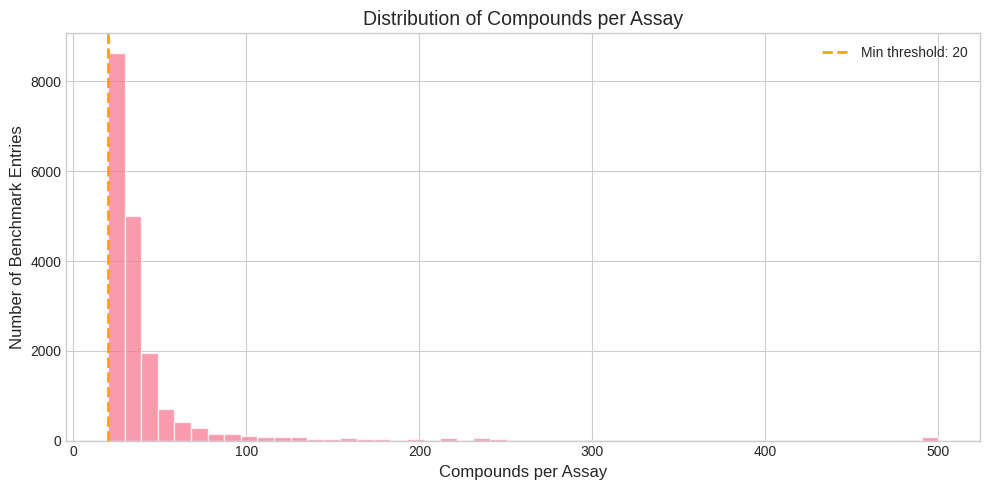

In [18]:
# Compounds per assay distribution
if 'n_compounds_in_assay' in df_bench.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Use log scale for better visualization
    data = df_bench['n_compounds_in_assay'].clip(upper=500)  # Clip outliers for visualization
    
    ax.hist(data, bins=50, edgecolor='white', alpha=0.7)
    ax.axvline(20, color='orange', linestyle='--', linewidth=2, label='Min threshold: 20')
    
    ax.set_xlabel('Compounds per Assay', fontsize=12)
    ax.set_ylabel('Number of Benchmark Entries', fontsize=12)
    ax.set_title('Distribution of Compounds per Assay', fontsize=14)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

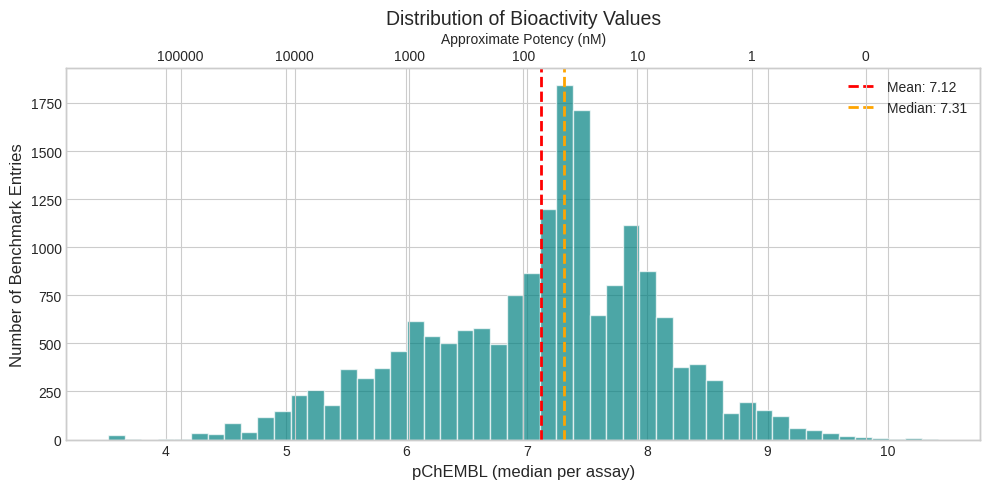

In [19]:
# pChEMBL distribution
if 'median_pchembl' in df_bench.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    pch_data = df_bench['median_pchembl'].dropna()
    
    ax.hist(pch_data, bins=50, edgecolor='white', alpha=0.7, color='teal')
    ax.axvline(pch_data.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {pch_data.mean():.2f}')
    ax.axvline(pch_data.median(), color='orange', linestyle='--', linewidth=2,
               label=f'Median: {pch_data.median():.2f}')
    
    ax.set_xlabel('pChEMBL (median per assay)', fontsize=12)
    ax.set_ylabel('Number of Benchmark Entries', fontsize=12)
    ax.set_title('Distribution of Bioactivity Values', fontsize=14)
    ax.legend()
    
    # Add secondary x-axis for nM
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    # Convert pChEMBL to nM: nM = 10^(9-pChEMBL)
    tick_locs = ax.get_xticks()
    ax2.set_xticks(tick_locs)
    ax2.set_xticklabels([f'{10**(9-x):.0f}' if 4 <= x <= 10 else '' for x in tick_locs])
    ax2.set_xlabel('Approximate Potency (nM)', fontsize=10)
    
    plt.tight_layout()
    plt.show()